# Fashion-MNIST: CNN + W&B Experiment Tracking
**Upgrade from MLP:**
- MLP treated each pixel independently (784 flat numbers)
- CNN exploits **spatial structure** — it sees the image as a 2D grid
- W&B logs every metric, lets you compare runs visually

**Expected accuracy:** ~92-94% (vs ~88-90% MLP)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Config — Single Source of Truth

Keeping all hyperparameters in one dict is good practice.
W&B logs this config alongside your metrics so you always know what produced what result.
When you want to try a new experiment, just change values here — nowhere else.

In [4]:
CONFIG = {
    # Data
    "batch_size": 64,

    # Architecture
    "conv1_filters": 32,
    "conv2_filters": 64,
    "conv3_filters": 128,
    
    "fc_hidden":     256,
    "dropout":       0.4,

    # Training
    "epochs":        20,
    "lr":            0.001,
    "weight_decay":  1e-4,    # L2 regularization in Adam
    "lr_schedule":   "cosine", # cosine annealing

    # W&B
    "project":       "fashion-mnist",
    "run_name":      "cnn-baseline",
}

## 2. Dataset

Key difference from MLP version: images are now shape **(1, 28, 28)** not **(784,)**.
CNN needs the 2D spatial layout — channels × height × width.

In [5]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

class FashionDataset(Dataset):
    def __init__(self, df):
        self.labels = torch.tensor(df['label'].values, dtype=torch.long)
        pixels = df.drop('label', axis=1).values.astype(np.float32)

        # Normalize to [0,1] then reshape to (N, 1, 28, 28)
        # The '1' is the channel dimension — grayscale = 1 channel (RGB would be 3)
        self.images = torch.tensor(pixels / 255.0).reshape(-1, 1, 28, 28)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


train_df = pd.read_csv('fashion-mnist_train.csv')
test_df  = pd.read_csv('fashion-mnist_test.csv')

train_dataset = FashionDataset(train_df)
test_dataset  = FashionDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

# Verify shape
imgs, lbls = next(iter(train_loader))
print(f"Image batch shape: {imgs.shape}")  # (64, 1, 28, 28)
print(f"Label batch shape: {lbls.shape}")  # (64,)

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


/Users/mclight/Downloads/GitHub/AI_Self-Study/.conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


## 3. CNN Architecture

### Why CNN beats MLP for images

MLP: every pixel connected to every neuron → ignores spatial relationships, tons of parameters

CNN uses two key operations:

**Conv2d** — slides a small filter (e.g. 3×3) across the image, learning to detect features like edges, curves, textures. Same filter applied everywhere = **translation invariance** (detects a shoe whether it's top-left or bottom-right)

**MaxPool2d** — downsamples by taking the max value in each region. Reduces spatial size, keeps strongest activations, adds robustness to small shifts.

```
Input:  (1, 28, 28)
  ↓  Conv2d(1→32, 3×3) + BN + ReLU   → (32, 28, 28)  detects low-level edges
  ↓  Conv2d(32→32, 3×3) + BN + ReLU  → (32, 28, 28)
  ↓  MaxPool2d(2×2)                   → (32, 14, 14)  halve spatial size
  ↓  Dropout2d(0.25)
  ↓  Conv2d(32→64, 3×3) + BN + ReLU  → (64, 14, 14)  detects mid-level shapes
  ↓  Conv2d(64→64, 3×3) + BN + ReLU  → (64, 14, 14)
  ↓  MaxPool2d(2×2)                   → (64, 7, 7)
  ↓  Dropout2d(0.25)
  ↓  Conv2d(64→128, 3×3) + BN + ReLU → (128, 5, 5)   detects high-level patterns
  ↓  AdaptiveAvgPool2d(1,1)           → (128, 1, 1)   global average pooling
  ↓  Flatten                          → (128,)
  ↓  Linear(128→256) + BN + ReLU
  ↓  Dropout(0.4)
  ↓  Linear(256→10)
Output: 10 logits
```

**BatchNorm** after each conv: normalizes activations across the batch → faster training, more stable gradients, acts as regularizer

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self, cfg):
        super(FashionCNN, self).__init__()

        c1 = cfg['conv1_filters']  
        c2 = cfg['conv2_filters']  
        c3 = cfg['conv3_filters']   
        fc = cfg['fc_hidden']       
        dp = cfg['dropout']      

        self.block1 = nn.Sequential(
            nn.Conv2d(1, c1, kernel_size=3, padding=1), 
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c1, c1, kernel_size=3, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),     
            nn.Dropout2d(0.25),      
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
            nn.Conv2d(c2, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),    
            nn.Dropout2d(0.25),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(c2, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c3, fc),
            nn.BatchNorm1d(fc),
            nn.ReLU(inplace=True),
            nn.Dropout(dp),
            nn.Linear(fc, 10),
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

if torch.cuda.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

model = FashionCNN(CONFIG).to(device)
print(model)
print(f"\nDevice: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

FashionCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)

## 4. Loss, Optimizer, LR Scheduler

**CosineAnnealingLR** — instead of a fixed learning rate, it starts at `lr` and smoothly decays to near-zero following a cosine curve over `T_max` epochs. This often squeezes out extra accuracy at the end of training because the model takes smaller, more precise steps near convergence.

/var/folders/0s/s2qqdkfs7_b9yv8pvrv2djp00000gn/T/ipykernel_23583/382330525.py:21: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  tmp_sched.step()


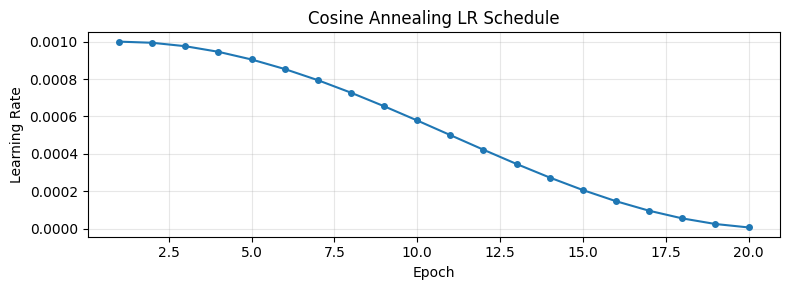

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']  # L2 penalty — discourages huge weights
)

# Cosine annealing: lr goes from 0.001 → ~0 over T_max epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['epochs'],
    eta_min=1e-6  # minimum lr
)

# Visualize the LR schedule
lrs = []
tmp_sched = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)
for _ in range(CONFIG['epochs']):
    lrs.append(tmp_sched.get_last_lr()[0])
    tmp_sched.step()

plt.figure(figsize=(8, 3))
plt.plot(range(1, CONFIG['epochs']+1), lrs, marker='o', markersize=4)
plt.title('Cosine Annealing LR Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Training Loop with W&B Logging

W&B works like this:
- `wandb.init()` — starts a run, logs your config
- `wandb.log({...})` — call every epoch with metrics dict
- `wandb.finish()` — closes the run cleanly

After training, go to https://wandb.ai/your-username/fashion-mnist to see your dashboard.

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels

In [9]:
import torch
print(torch.__version__)
print(torch.backends.mps.is_available())
print(torch.backends.mps.is_built())

2.12.0
True
True


In [10]:
# Safe device setup — fallback to CPU if MPS is unstable
device = torch.device('cpu')  # force CPU for now
print(f"Using device: {device}")

# Rebuild model on correct device
model = FashionCNN(CONFIG).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)

# Smaller batch size to be safe
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc = 0.0

for epoch in range(1, CONFIG['epochs'] + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, preds, labels_list = evaluate(model, test_loader, criterion, device)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'fashion_cnn_best.pth')

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch:2d}/{CONFIG['epochs']} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.4f} | "
          f"LR: {current_lr:.6f}")

print(f"\nBest Test Accuracy: {best_acc:.4f}")

Using device: cpu
Epoch  1/20 | Train Loss: 0.6627 Acc: 0.7560 | Test Loss: 0.3805 Acc: 0.8543 | LR: 0.000994
Epoch  2/20 | Train Loss: 0.4117 Acc: 0.8506 | Test Loss: 0.2802 Acc: 0.8946 | LR: 0.000976
Epoch  3/20 | Train Loss: 0.3448 Acc: 0.8752 | Test Loss: 0.2727 Acc: 0.8985 | LR: 0.000946
Epoch  4/20 | Train Loss: 0.3049 Acc: 0.8905 | Test Loss: 0.2283 Acc: 0.9118 | LR: 0.000905
Epoch  5/20 | Train Loss: 0.2817 Acc: 0.8985 | Test Loss: 0.2076 Acc: 0.9228 | LR: 0.000854
Epoch  6/20 | Train Loss: 0.2637 Acc: 0.9058 | Test Loss: 0.1993 Acc: 0.9261 | LR: 0.000794
Epoch  7/20 | Train Loss: 0.2470 Acc: 0.9111 | Test Loss: 0.1908 Acc: 0.9294 | LR: 0.000727
Epoch  8/20 | Train Loss: 0.2366 Acc: 0.9137 | Test Loss: 0.1877 Acc: 0.9309 | LR: 0.000655
Epoch  9/20 | Train Loss: 0.2252 Acc: 0.9190 | Test Loss: 0.1787 Acc: 0.9354 | LR: 0.000579
Epoch 10/20 | Train Loss: 0.2116 Acc: 0.9244 | Test Loss: 0.1742 Acc: 0.9363 | LR: 0.000501
Epoch 11/20 | Train Loss: 0.2019 Acc: 0.9264 | Test Loss: 0.18

In [34]:
# Training without W&B — runs clean on MPS Mac
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc = 0.0

for epoch in range(1, CONFIG['epochs'] + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, preds, labels_list = evaluate(model, test_loader, criterion, device)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'fashion_cnn_best.pth')

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch {epoch:2d}/{CONFIG['epochs']} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.4f} | "
          f"LR: {current_lr:.6f}")

print(f"\nBest Test Accuracy: {best_acc:.4f}")

/Users/mclight/Downloads/GitHub/AI_Self-Study/.conda/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


: 

## 6. Plot Training Curves (local)

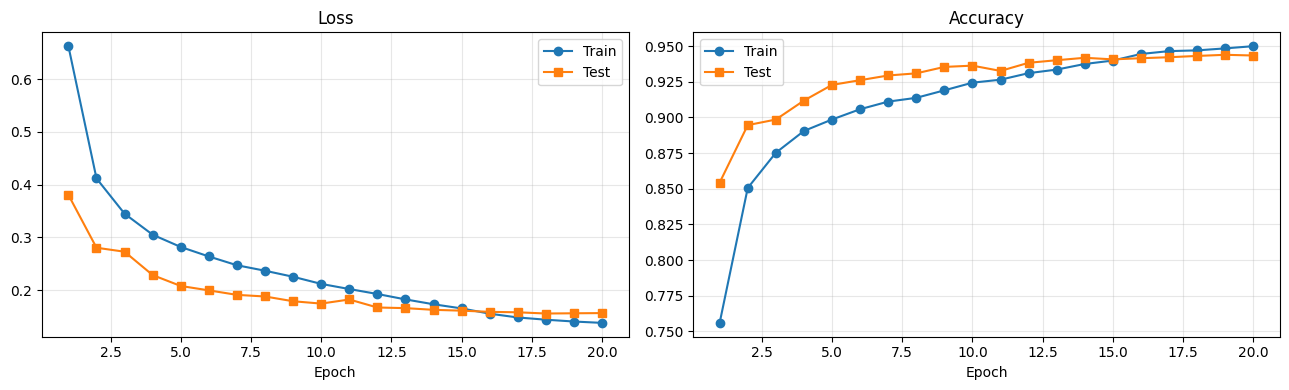

In [11]:
epochs_range = range(1, CONFIG['epochs'] + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_range, history['train_loss'], label='Train', marker='o')
ax1.plot(epochs_range, history['test_loss'],  label='Test',  marker='s')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], label='Train', marker='o')
ax2.plot(epochs_range, history['test_acc'],  label='Test',  marker='s')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Confusion Matrix — Where Does It Fail?

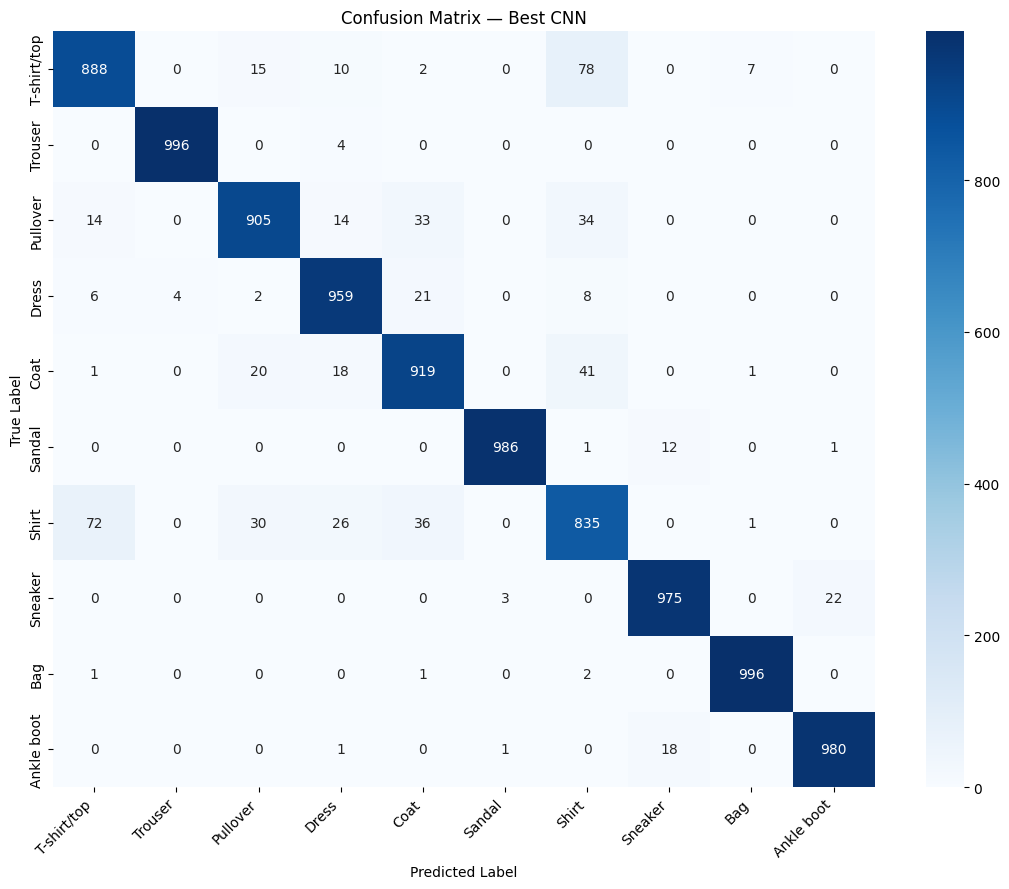


Per-class accuracy:
  T-shirt/top     0.888
  Trouser         0.996
  Pullover        0.905
  Dress           0.959
  Coat            0.919
  Sandal          0.986
  Shirt           0.835
  Sneaker         0.975
  Bag             0.996
  Ankle boot      0.980


In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Load best model for final evaluation
model.load_state_dict(torch.load('fashion_cnn_best.pth'))
_, _, final_preds, final_labels = evaluate(model, test_loader, criterion, device)

cm = confusion_matrix(final_labels, final_preds)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix — Best CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print per-class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"  {name:<15} {class_acc:.3f}")

## 8. Visualize What the CNN Learned — Filter Visualization

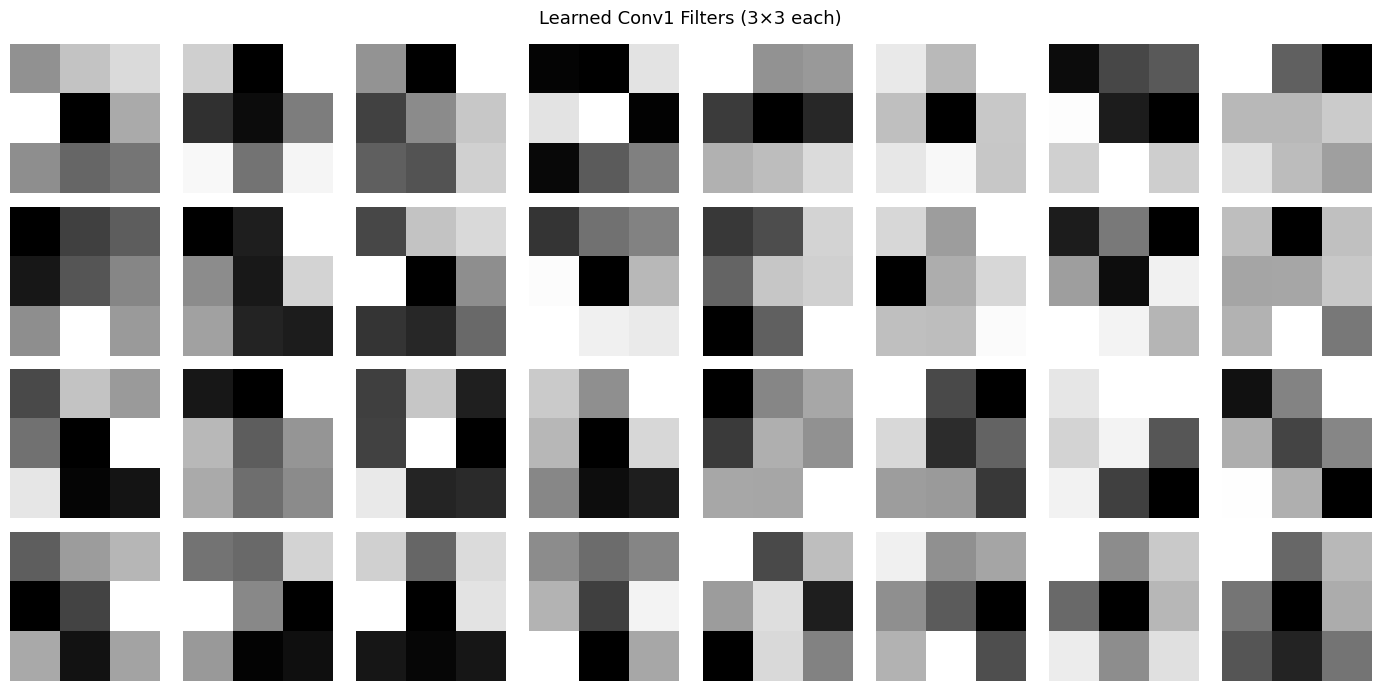

In [13]:
# Visualize the 32 learned filters from the first Conv2d layer
# These are the patterns the CNN looks for at the lowest level (edges, textures)

filters = model.block1[0].weight.data.cpu()  # shape: (32, 1, 3, 3)

# Normalize to [0, 1] for display
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap='gray', interpolation='nearest')
    ax.axis('off')
plt.suptitle('Learned Conv1 Filters (3×3 each)', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Run a Second Experiment — Compare in W&B

This is where W&B shines. Change one thing, give it a new name, run again.
Your dashboard will show both runs side by side automatically.

## Summary

### CNN vs MLP
```
MLP  → flat 784 vector → ignores spatial structure → ~88-90%
CNN  → 2D (1,28,28)   → learns local features    → ~92-94%
```

### What each upgrade added
```
Conv2d          → local feature detection, translation invariance
BatchNorm       → stable gradients, faster convergence
Dropout2d       → drops full channels, stronger regularization
AdaptiveAvgPool → size-agnostic global pooling
CosineAnnealingLR → smooth LR decay, better final accuracy
weight_decay    → L2 regularization baked into Adam
W&B             → full experiment tracking, compare runs visually
```

### What to try next
- **Data augmentation** — `RandomHorizontalFlip`, `RandomCrop` → another +1-2%
- **ResNet-style skip connections** — add residual blocks
- **Optuna** — automated hyperparameter search, logs to W&B automatically
- **TorchScript / ONNX export** — deploy the model